# 17 - ResNet101 transfer learning mejorado con TTA

Evolucion del `11_resnet_transfer_learning`: mantiene la misma forma de leer datos y generar el zip para Codabench, pero busca mejorar el rendimiento usando una backbone mas potente (`ResNet101`), augmentation suave, fine-tuning en 3 etapas, `label_smoothing`, `AdamW` y prediccion con TTA.


## Librerias y configuracion


In [1]:
import json
import time
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RUN_START = time.perf_counter()

gpus = tf.config.list_physical_devices('GPU')
print('GPUs disponibles:', gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print('No se pudo activar memory_growth:', exc)


2026-06-08 17:13:27.635148: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780938807.855033      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780938807.922381      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780938808.436628      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780938808.436672      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780938808.436675      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
SEED = 42
BATCH_SIZE = 24
EPOCHS_STAGE1 = 12
EPOCHS_STAGE2 = 18
EPOCHS_STAGE3 = 12
VALIDATION_SIZE = 0.15
IMAGE_SHAPE = (224, 224, 3)

LR_STAGE1 = 3e-4
LR_STAGE2 = 1e-5
LR_STAGE3 = 3e-6
WEIGHT_DECAY_HEAD = 1e-5
WEIGHT_DECAY_FINE = 1e-6
LABEL_SMOOTHING = 0.03

STAGE2_TRAINABLE_LAST = 80
STAGE3_TRAINABLE_LAST = 160

USE_MIXED_PRECISION = True
USE_TTA_VALIDATION = True
USE_TTA_CODABENCH = True
TTA_BATCH_SIZE = 48

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

if USE_MIXED_PRECISION and gpus:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

print('Politica de precision:', tf.keras.mixed_precision.global_policy())


Politica de precision: <DTypePolicy "mixed_float16">


## Datos


### Localizacion de inputs


In [3]:
KAGGLE_INPUT_DIR = Path('/kaggle/input')
WORKDIR = Path('/kaggle/working')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError('No existe /kaggle/input. Ejecuta este notebook en Kaggle.')

array_dirs = sorted({p.parent for p in KAGGLE_INPUT_DIR.rglob('X_all.npy')})
if not array_dirs:
    raise FileNotFoundError('No se encontro X_all.npy. Anade el dataset xview_arrays como Input.')

ARRAYS_DIR = array_dirs[0]

ann_candidates = sorted(
    p for p in KAGGLE_INPUT_DIR.rglob('xview_ann_train.json')
    if (p.parent / 'xview_test').exists()
)
if not ann_candidates:
    raise FileNotFoundError('No se encontro xview_ann_train.json con carpeta xview_test al lado. Anade xview_recognition como Input.')

ANN_JSON = ann_candidates[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'

print('ARRAYS_DIR:', ARRAYS_DIR)
print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


ARRAYS_DIR: /kaggle/input/datasets/eccvdl/xview-arrays/xview_arrays
DATA_ROOT: /kaggle/input/datasets/eccvdl/xview-recognition
ANN_JSON: /kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


### Lectura de arrays


In [4]:
DATA_LOAD_START = time.perf_counter()

X_all = np.load(ARRAYS_DIR / 'X_all.npy')
y_all_idx = np.load(ARRAYS_DIR / 'y_all_idx.npy')
filenames = np.load(ARRAYS_DIR / 'filenames.npy').astype(str)
image_ids = np.load(ARRAYS_DIR / 'image_ids.npy').astype(str)
category_names = np.load(ARRAYS_DIR / 'category_names.npy').astype(str).tolist()

metadata_path = ARRAYS_DIR / 'metadata.json'
if metadata_path.exists():
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
else:
    metadata = {}

num_classes = len(category_names)

print('X_all:', X_all.shape, X_all.dtype, 'RAM aprox:', X_all.nbytes / 1024**3, 'GB')
print('y_all_idx:', y_all_idx.shape, y_all_idx.dtype)
print('filenames:', filenames.shape)
print('image_ids:', image_ids.shape)
print('num_classes:', num_classes)
print('category_names:', category_names)
print('metadata:', metadata)


X_all: (18746, 224, 224, 3) uint8 RAM aprox: 2.6280040740966797 GB
y_all_idx: (18746,) int32
filenames: (18746,)
image_ids: (18746,)
num_classes: 13
category_names: ['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon']
metadata: {'num_images': 18746, 'image_shape': [224, 224, 3], 'x_dtype': 'uint8', 'y_dtype': 'int32', 'category_names': ['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon'], 'category_to_idx': {'Cargo plane': 0, 'Small car': 1, 'Bus': 2, 'Truck': 3, 'Motorboat': 4, 'Fishing vessel': 5, 'Dump truck': 6, 'Excavator': 7, 'Building': 8, 'Helipad': 9, 'Storage tank': 10, 'Shipping container': 11, 'Pylon': 12}, 'source_ann_json': '/kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json'}


### Comprobacion de una imagen


filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
image_id: 0234476c-a017-4c9b-bd2f-872193076cca.tif
label idx: 8
label name: Building
shape: (224, 224, 3) dtype: uint8
Primeros pixeles del array:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]


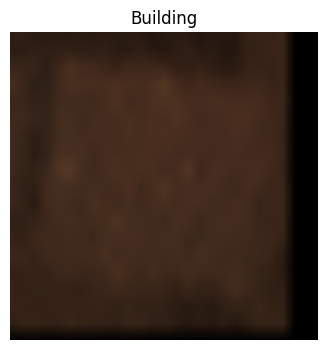

In [5]:
sample_idx = 0
sample_image = X_all[sample_idx]
sample_label_idx = int(y_all_idx[sample_idx])

print('filename:', filenames[sample_idx])
print('image_id:', image_ids[sample_idx])
print('label idx:', sample_label_idx)
print('label name:', category_names[sample_label_idx])
print('shape:', sample_image.shape, 'dtype:', sample_image.dtype)
print('Primeros pixeles del array:')
print(sample_image[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(category_names[sample_label_idx])
plt.axis('off')
plt.show()


### Split train/valid


In [6]:
indices = np.arange(len(X_all))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=y_all_idx,
)

X_train = X_all[train_idx]
X_valid = X_all[val_idx]
y_train_idx = y_all_idx[train_idx]
y_valid_idx = y_all_idx[val_idx]

y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes=num_classes).astype(np.float32)
y_valid = tf.keras.utils.to_categorical(y_valid_idx, num_classes=num_classes).astype(np.float32)

DATA_LOAD_TIME = time.perf_counter() - DATA_LOAD_START

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)
print(f'Tiempo carga arrays/split: {DATA_LOAD_TIME:.2f} s')


X_train: (15934, 224, 224, 3) uint8 RAM aprox: 2.2337894439697266 GB
X_valid: (2812, 224, 224, 3) uint8 RAM aprox: 0.3942146301269531 GB
y_train: (15934, 13) float32
y_valid: (2812, 13) float32
Tiempo carga arrays/split: 13.21 s


## Red


### ResNet101 preentrenada


In [7]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.04, fill_mode='reflect', seed=SEED + 1),
    tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode='reflect', seed=SEED + 2),
    tf.keras.layers.RandomZoom(0.05, fill_mode='reflect', seed=SEED + 3),
], name='augmentation_suave')

resnet_preprocess = tf.keras.applications.resnet.preprocess_input

inputs = tf.keras.Input(shape=IMAGE_SHAPE, name='image')
x = data_aug(inputs)
x = tf.keras.layers.Lambda(resnet_preprocess, name='resnet101_preprocess')(x)

base = tf.keras.applications.ResNet101(
    include_top=False,
    weights='imagenet',
    input_tensor=x,
)

base.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(base.output)
x = tf.keras.layers.BatchNormalization(name='head_bn_1')(x)
x = tf.keras.layers.Dropout(0.35, name='head_dropout_1')(x)
x = tf.keras.layers.Dense(
    512,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name='head_dense',
)(x)
x = tf.keras.layers.BatchNormalization(name='head_bn_2')(x)
x = tf.keras.layers.Dropout(0.35, name='head_dropout_2')(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)

model = tf.keras.Model(inputs, outputs, name='resnet101_transfer_tta')
model.summary()


I0000 00:00:1780938848.508988      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780938848.514905      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet101_transfer_tta"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_suave  │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet101_preproce… │ (None, 224, 224,  │          0 │ augmentation_sua… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ resnet101_prepro… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r

 Total params: 43,724,173 (166.79 MB)

 Trainable params: 1,060,877 (4.05 MB)

 Non-trainable params: 42,663,296 (162.75 MB)

### Funciones de entrenamiento


In [8]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)


def make_optimizer(learning_rate, weight_decay):
    try:
        return tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
    except Exception:
        print('AdamW no disponible; usando Adam.')
        return tf.keras.optimizers.Adam(learning_rate=learning_rate)


def compile_model(learning_rate, weight_decay):
    model.compile(
        optimizer=make_optimizer(learning_rate, weight_decay),
        loss=loss_fn,
        metrics=['accuracy'],
    )


def make_callbacks(model_path, patience=6):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            str(model_path),
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            mode='max',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.TerminateOnNaN(),
    ]


def set_backbone_trainable(backbone, trainable_last_n):
    backbone.trainable = True
    for layer in backbone.layers:
        layer.trainable = False

    if trainable_last_n > 0:
        for layer in backbone.layers[-trainable_last_n:]:
            layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)

    for layer in backbone.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    trainable_layers = sum(int(layer.trainable) for layer in backbone.layers)
    print(f'Capas entrenables en backbone: {trainable_layers}/{len(backbone.layers)}')


### Funcion de graficas


In [9]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history.get('accuracy', []), label='train')
    axes[0].plot(history.history.get('val_accuracy', []), label='valid')
    axes[0].set_title(f'{title} - accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history.get('loss', []), label='train')
    axes[1].plot(history.history.get('val_loss', []), label='valid')
    axes[1].set_title(f'{title} - loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


### Entrenamiento stage 1


In [10]:
MODEL_PATH_STAGE1 = WORKDIR / '17_resnet101_stage1.weights.h5'

for layer in base.layers:
    layer.trainable = False

compile_model(LR_STAGE1, WEIGHT_DECAY_HEAD)
callbacks_stage1 = make_callbacks(MODEL_PATH_STAGE1, patience=5)

STAGE1_START = time.perf_counter()

history_stage1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_stage1,
    verbose=1,
)

STAGE1_TIME = time.perf_counter() - STAGE1_START

best_idx_stage1 = int(np.argmax(history_stage1.history['val_accuracy']))
best_value_stage1 = float(np.max(history_stage1.history['val_accuracy']))
print('Best stage 1 model: epoch', best_idx_stage1 + 1, '- val_accuracy', best_value_stage1)
print(f'Tiempo stage 1: {STAGE1_TIME:.2f} s')


Epoch 1/12


I0000 00:00:1780938875.914816     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4897 - loss: 1.9627
Epoch 1: val_accuracy improved from None to 0.67639, saving model to /kaggle/working/17_resnet101_stage1.weights.h5

Epoch 1: finished saving model to /kaggle/working/17_resnet101_stage1.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 106s 130ms/step - accuracy: 0.5560 - loss: 1.6963 - val_accuracy: 0.6764 - val_loss: 1.2266 - learning_rate: 3.0000e-04
Epoch 2/12
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6190 - loss: 1.4043
Epoch 2: val_accuracy improved from 0.67639 to 0.70590, saving model to /kaggle/working/17_resnet101_stage1.weights.h5

Epoch 2: finished saving model to /kaggle/working/17_resnet101_stage1.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 82s 123ms/step - accuracy: 0.6295 - loss: 1.3712 - val_accuracy: 0.7059 - val_loss: 1.1440 - learning_rate: 3.0000e-04
Epoch 3/12
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6516 - loss: 1.2701
Epoch 3: val_accuracy improved from 0.70590 to 0.71

### Graficas stage 1


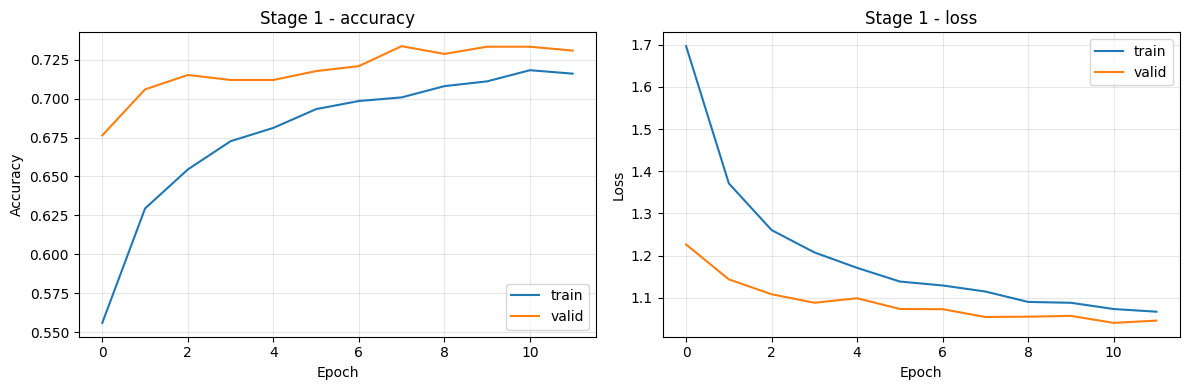

In [11]:
plot_history(history_stage1, 'Stage 1')


### Fine-tuning stage 2


In [12]:
model.load_weights(MODEL_PATH_STAGE1)
set_backbone_trainable(base, STAGE2_TRAINABLE_LAST)

MODEL_PATH_STAGE2 = WORKDIR / '17_resnet101_stage2.weights.h5'
compile_model(LR_STAGE2, WEIGHT_DECAY_FINE)
callbacks_stage2 = make_callbacks(MODEL_PATH_STAGE2, patience=6)

STAGE2_START = time.perf_counter()

history_stage2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2,
    verbose=1,
)

STAGE2_TIME = time.perf_counter() - STAGE2_START

best_idx_stage2 = int(np.argmax(history_stage2.history['val_accuracy']))
best_value_stage2 = float(np.max(history_stage2.history['val_accuracy']))
print('Best stage 2 model: epoch', best_idx_stage2 + 1, '- val_accuracy', best_value_stage2)
print(f'Tiempo stage 2: {STAGE2_TIME:.2f} s')


Capas entrenables en backbone: 56/347
Epoch 1/18
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7225 - loss: 1.0582
Epoch 1: val_accuracy improved from None to 0.74324, saving model to /kaggle/working/17_resnet101_stage2.weights.h5

Epoch 1: finished saving model to /kaggle/working/17_resnet101_stage2.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 137s 170ms/step - accuracy: 0.7304 - loss: 1.0433 - val_accuracy: 0.7432 - val_loss: 1.0154 - learning_rate: 1.0000e-05
Epoch 2/18
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7439 - loss: 0.9963
Epoch 2: val_accuracy improved from 0.74324 to 0.75000, saving model to /kaggle/working/17_resnet101_stage2.weights.h5

Epoch 2: finished saving model to /kaggle/working/17_resnet101_stage2.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 105s 158ms/step - accuracy: 0.7455 - loss: 0.9888 - val_accuracy: 0.7500 - val_loss: 0.9900 - learning_rate: 1.0000e-05
Epoch 3/18
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7647 - loss: 0.9583
E

### Graficas stage 2


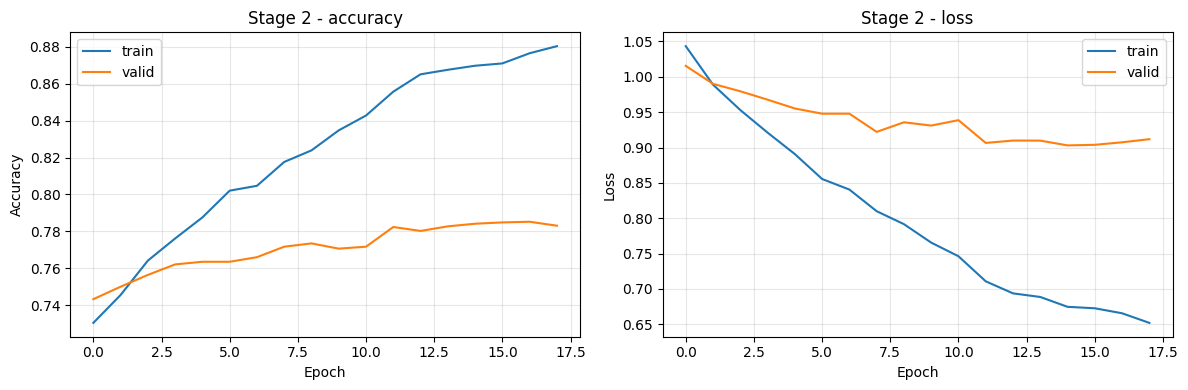

In [13]:
plot_history(history_stage2, 'Stage 2')


### Fine-tuning stage 3


In [14]:
model.load_weights(MODEL_PATH_STAGE2)
set_backbone_trainable(base, STAGE3_TRAINABLE_LAST)

MODEL_PATH_STAGE3 = WORKDIR / '17_resnet101_stage3.weights.h5'
compile_model(LR_STAGE3, WEIGHT_DECAY_FINE)
callbacks_stage3 = make_callbacks(MODEL_PATH_STAGE3, patience=5)

STAGE3_START = time.perf_counter()

history_stage3 = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_STAGE3,
    callbacks=callbacks_stage3,
    verbose=1,
)

STAGE3_TIME = time.perf_counter() - STAGE3_START

best_idx_stage3 = int(np.argmax(history_stage3.history['val_accuracy']))
best_value_stage3 = float(np.max(history_stage3.history['val_accuracy']))
print('Best stage 3 model: epoch', best_idx_stage3 + 1, '- val_accuracy', best_value_stage3)
print(f'Tiempo stage 3: {STAGE3_TIME:.2f} s')


Capas entrenables en backbone: 112/347
Epoch 1/12
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8794 - loss: 0.6576
Epoch 1: val_accuracy improved from None to 0.78272, saving model to /kaggle/working/17_resnet101_stage3.weights.h5

Epoch 1: finished saving model to /kaggle/working/17_resnet101_stage3.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 157s 195ms/step - accuracy: 0.8814 - loss: 0.6546 - val_accuracy: 0.7827 - val_loss: 0.9063 - learning_rate: 3.0000e-06
Epoch 2/12
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8830 - loss: 0.6430
Epoch 2: val_accuracy did not improve from 0.78272
664/664 ━━━━━━━━━━━━━━━━━━━━ 121s 182ms/step - accuracy: 0.8820 - loss: 0.6440 - val_accuracy: 0.7824 - val_loss: 0.9127 - learning_rate: 3.0000e-06
Epoch 3/12
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8892 - loss: 0.6375
Epoch 3: val_accuracy improved from 0.78272 to 0.78449, saving model to /kaggle/working/17_resnet101_stage3.weights.h5

Epoch 3: finished saving model

### Graficas stage 3


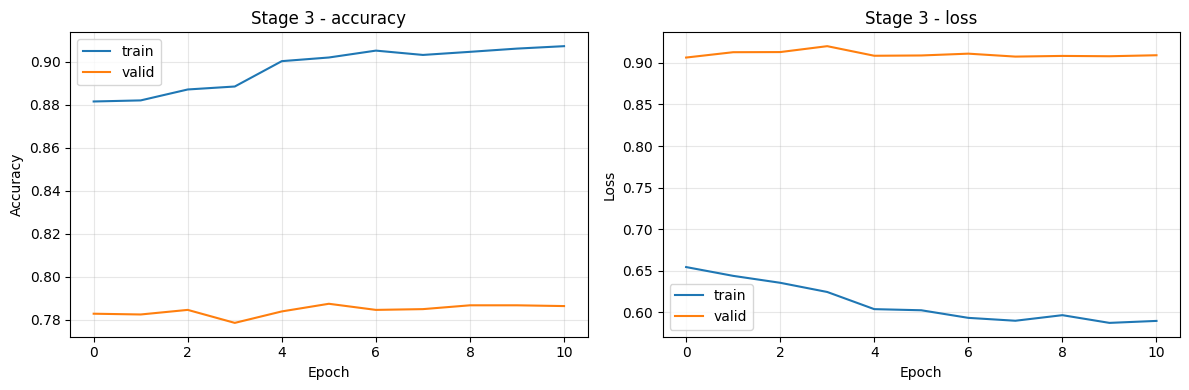

In [15]:
plot_history(history_stage3, 'Stage 3')


### Seleccion del mejor stage


In [16]:
stage_results = [
    ('stage1', best_value_stage1, MODEL_PATH_STAGE1),
    ('stage2', best_value_stage2, MODEL_PATH_STAGE2),
    ('stage3', best_value_stage3, MODEL_PATH_STAGE3),
]

BEST_STAGE, BEST_VAL_ACCURACY, MODEL_PATH = max(stage_results, key=lambda item: item[1])
model.load_weights(MODEL_PATH)

print('Mejor stage:', BEST_STAGE)
print('Mejor val_accuracy registrada:', BEST_VAL_ACCURACY)
print('Modelo seleccionado:', MODEL_PATH)


Mejor stage: stage3
Mejor val_accuracy registrada: 0.787339985370636
Modelo seleccionado: /kaggle/working/17_resnet101_stage3.weights.h5


## Resultados


### Predicciones de validacion


In [17]:
def predict_with_tta_array(model, images, batch_size=64, use_tta=True, verbose=0):
    variants = [('identity', images)]
    if use_tta:
        variants.extend([
            ('hflip', np.flip(images, axis=2)),
            ('vflip', np.flip(images, axis=1)),
            ('rot90', np.rot90(images, k=1, axes=(1, 2))),
            ('rot180', np.rot90(images, k=2, axes=(1, 2))),
            ('rot270', np.rot90(images, k=3, axes=(1, 2))),
        ])

    probs_sum = None
    for name, variant in variants:
        variant = np.ascontiguousarray(variant)
        probs = model.predict(variant, batch_size=batch_size, verbose=verbose)
        probs_sum = probs if probs_sum is None else probs_sum + probs
        print('TTA variant procesada:', name)

    return probs_sum / len(variants)


model.load_weights(MODEL_PATH)

valid_loss, valid_accuracy = model.evaluate(X_valid, y_valid, batch_size=BATCH_SIZE, verbose=1)
print('Validation loss normal:', valid_loss)
print('Validation accuracy normal:', valid_accuracy)

plain_probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
plain_pred_idx = np.argmax(plain_probs, axis=1)
plain_accuracy = accuracy_score(y_valid_idx, plain_pred_idx)
print('Plain validation accuracy:', plain_accuracy)

if USE_TTA_VALIDATION:
    tta_probs = predict_with_tta_array(model, X_valid, batch_size=TTA_BATCH_SIZE, use_tta=True, verbose=0)
    tta_pred_idx = np.argmax(tta_probs, axis=1)
    tta_accuracy = accuracy_score(y_valid_idx, tta_pred_idx)
    print('TTA validation accuracy:', tta_accuracy)

    if tta_accuracy >= plain_accuracy:
        probs = tta_probs
        y_pred_idx = tta_pred_idx
        PREDICTION_MODE = 'tta'
    else:
        probs = plain_probs
        y_pred_idx = plain_pred_idx
        PREDICTION_MODE = 'plain'
else:
    probs = plain_probs
    y_pred_idx = plain_pred_idx
    PREDICTION_MODE = 'plain'

y_true_idx = y_valid_idx
print('Modo usado para resultados:', PREDICTION_MODE)

USE_TTA_CODABENCH_EFFECTIVE = bool(USE_TTA_CODABENCH and (PREDICTION_MODE == 'tta' or not USE_TTA_VALIDATION))
print('TTA en Codabench:', USE_TTA_CODABENCH_EFFECTIVE)


118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.7873 - loss: 0.9088
Validation loss normal: 0.9088142514228821
Validation accuracy normal: 0.787339985370636
118/118 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step
Plain validation accuracy: 0.7873399715504978
TTA variant procesada: identity
TTA variant procesada: hflip
TTA variant procesada: vflip
TTA variant procesada: rot90
TTA variant procesada: rot180
TTA variant procesada: rot270
TTA validation accuracy: 0.7958748221906117
Modo usado para resultados: tta
TTA en Codabench: True


### Matriz de confusion


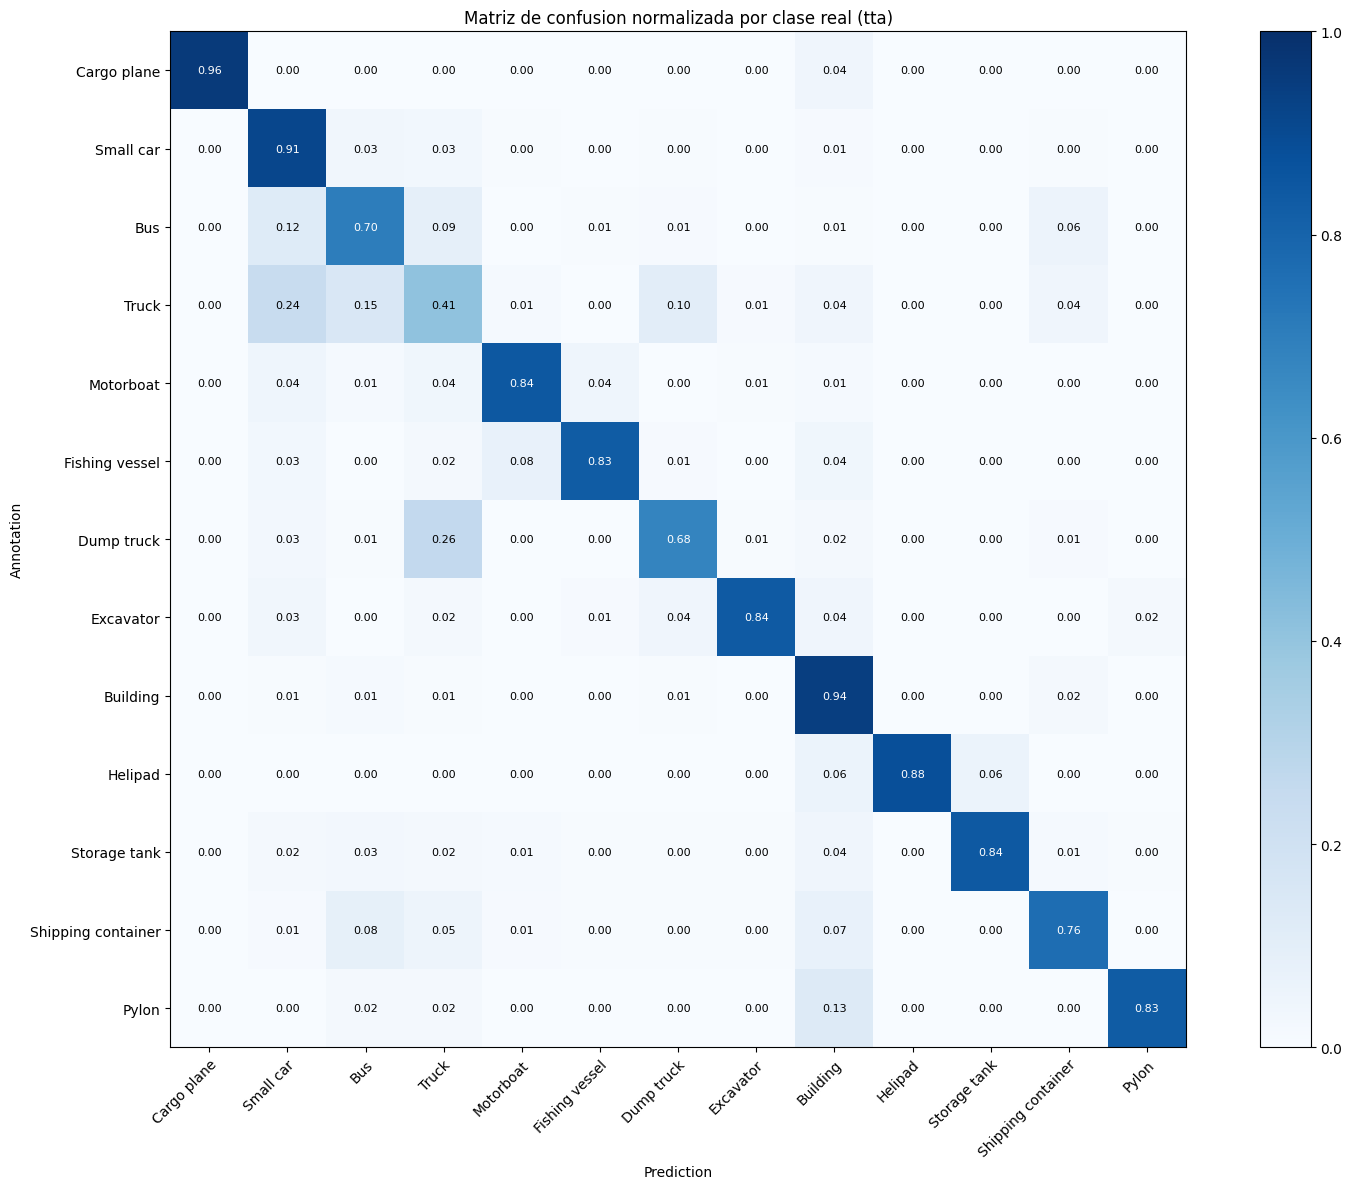

In [18]:
cm = confusion_matrix(y_true_idx, y_pred_idx, labels=np.arange(num_classes), normalize='true')

fig, ax = plt.subplots(figsize=(16, 12))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
fig.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(num_classes),
    yticks=np.arange(num_classes),
    xticklabels=category_names,
    yticklabels=category_names,
    ylabel='Annotation',
    xlabel='Prediction',
    title=f'Matriz de confusion normalizada por clase real ({PREDICTION_MODE})',
)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

for i in range(num_classes):
    for j in range(num_classes):
        value = cm[i, j]
        color = 'white' if value > 0.5 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()


### Metricas


In [19]:
print(classification_report(
    y_true_idx,
    y_pred_idx,
    labels=np.arange(num_classes),
    target_names=category_names,
    digits=4,
))


                    precision    recall  f1-score   support

       Cargo plane     0.9891    0.9579    0.9733        95
         Small car     0.7625    0.9138    0.8314       499
               Bus     0.6436    0.7019    0.6715       265
             Truck     0.5378    0.4066    0.4631       332
         Motorboat     0.8654    0.8438    0.8544       160
    Fishing vessel     0.8713    0.8302    0.8502       106
        Dump truck     0.7143    0.6757    0.6944       185
         Excavator     0.9252    0.8390    0.8800       118
          Building     0.8791    0.9443    0.9106       539
           Helipad     1.0000    0.8824    0.9375        17
      Storage tank     0.9893    0.8409    0.9091       220
Shipping container     0.7955    0.7642    0.7795       229
             Pylon     0.9286    0.8298    0.8764        47

          accuracy                         0.7959      2812
         macro avg     0.8386    0.8023    0.8178      2812
      weighted avg     0.7930    0.795

## Codabench


### Generacion del submission


In [20]:
CODABENCH_START = time.perf_counter()


def load_test_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))


test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))
assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'

model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
use_tta_codabench = globals().get('USE_TTA_CODABENCH_EFFECTIVE', USE_TTA_CODABENCH)
print('Usando TTA para Codabench:', use_tta_codabench)
batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_test_image(filename) for filename in load_filenames]).astype(np.uint8)
    probs_batch = predict_with_tta_array(
        model,
        images,
        batch_size=TTA_BATCH_SIZE,
        use_tta=use_tta_codabench,
        verbose=0,
    )
    pred_idx = np.argmax(probs_batch, axis=1)
    pred_scores = np.max(probs_batch, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_17.json'
submission_path = WORKDIR / 'submission_17.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

CODABENCH_TIME = time.perf_counter() - CODABENCH_START

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
print(f'Tiempo Codabench: {CODABENCH_TIME:.2f} s')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Number of testing images: 2365
Usando TTA para Codabench: True
TTA variant procesada: identity
TTA variant procesada: hflip
TTA variant procesada: vflip
TTA variant procesada: rot90
TTA variant procesada: rot180
TTA variant procesada: rot270
Procesadas 64/2365
TTA variant procesada: identity
TTA variant procesada: hflip
TTA variant procesada: vflip
TTA variant procesada: rot90
TTA variant procesada: rot180
TTA variant procesada: rot270
Procesadas 128/2365
TTA variant procesada: identity
TTA variant procesada: hflip
TTA variant procesada: vflip
TTA variant procesada: rot90
TTA variant procesada: rot180
TTA variant procesada: rot270
Procesadas 192/2365
TTA variant procesada: identity
TTA variant procesada: hflip
TTA variant procesada: vflip
TTA variant procesada: rot90
TTA variant procesada: rot180
TTA variant procesada: rot270
Procesadas 256/2365
TTA variant procesada: identity
TTA variant procesada: hflip
TTA variant procesada: vflip
TTA variant procesada: rot90
TTA variant procesada: 

/kaggle/working/submission_17.zip

### Resumen de tiempos


In [21]:
TOTAL_TIME = time.perf_counter() - RUN_START
print('Resumen de tiempos')
if 'DATA_LOAD_TIME' in globals():
    print(f'- Carga/preparacion de datos: {DATA_LOAD_TIME:.2f} s')
if 'STAGE1_TIME' in globals():
    print(f'- Stage 1: {STAGE1_TIME:.2f} s')
if 'STAGE2_TIME' in globals():
    print(f'- Stage 2: {STAGE2_TIME:.2f} s')
if 'STAGE3_TIME' in globals():
    print(f'- Stage 3: {STAGE3_TIME:.2f} s')
if 'CODABENCH_TIME' in globals():
    print(f'- Codabench: {CODABENCH_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME / 60:.2f} min')


Resumen de tiempos
- Carga/preparacion de datos: 13.21 s
- Stage 1: 999.49 s
- Stage 2: 1910.23 s
- Stage 3: 1372.33 s
- Codabench: 97.69 s
- Tiempo total Run All: 4528.88 s
- Tiempo total Run All: 75.48 min
